In [12]:
# Load Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [13]:
# Load the Iris Dataset
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['Species'] = iris.target_names[iris.target]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
# Display feature names
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [15]:
# Display target names
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [16]:
# Shape and basic info
print('Shape of dataset:', iris_df.shape)
print('\nSpecies counts:')
print(iris_df['Species'].value_counts())

Shape of dataset: (150, 5)

Species counts:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [17]:
# Separate features and target
X = iris_df.drop('Species', axis=1)
y = iris_df['Species']

# Standardize the features (recommended before t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled features shape:', X_scaled.shape)

Scaled features shape: (150, 4)


In [18]:
# Apply t-SNE with n_components=2
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print('t-SNE output shape:', X_tsne.shape)
print('KL Divergence (final):', tsne.kl_divergence_)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE output shape: (150, 2)
KL Divergence (final): 0.17288459837436676


In [20]:
# Apply t-SNE with perplexity=100
tsne = TSNE(n_components=2, perplexity=100, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print('t-SNE output shape:', X_tsne.shape)
print('KL Divergence (final):', tsne.kl_divergence_)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE output shape: (150, 2)
KL Divergence (final): 0.012114930897951126


In [22]:
# Create DataFrame for 2D t-SNE results
tsne_df = pd.DataFrame(X_tsne, columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['Species'] = y
tsne_df.head()

,t-SNE Component 1,t-SNE Component 2,Species
0,-14.231031,-0.229358,setosa
1,-14.607391,-0.697540,setosa
2,-14.376660,-0.615408,setosa
3,-14.471165,-0.705499,setosa
4,-14.125587,-0.195529,setosa


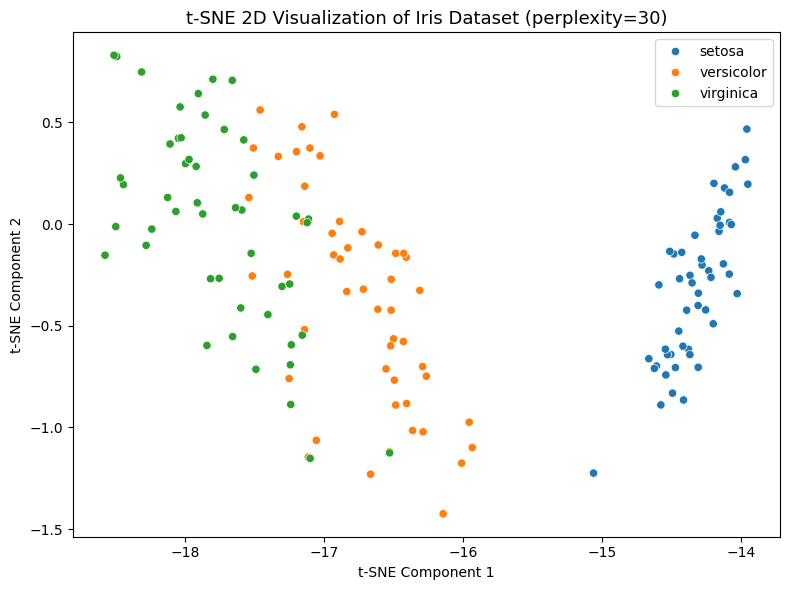

In [26]:
# Plot 2D t-SNE
plt.figure(figsize=(8, 6))

sns.scatterplot(x='t-SNE Component 1', y='t-SNE Component 2', hue='Species', data=tsne_df)

plt.title('t-SNE 2D Visualization of Iris Dataset (perplexity=30)', fontsize=13)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.tight_layout()
plt.show()

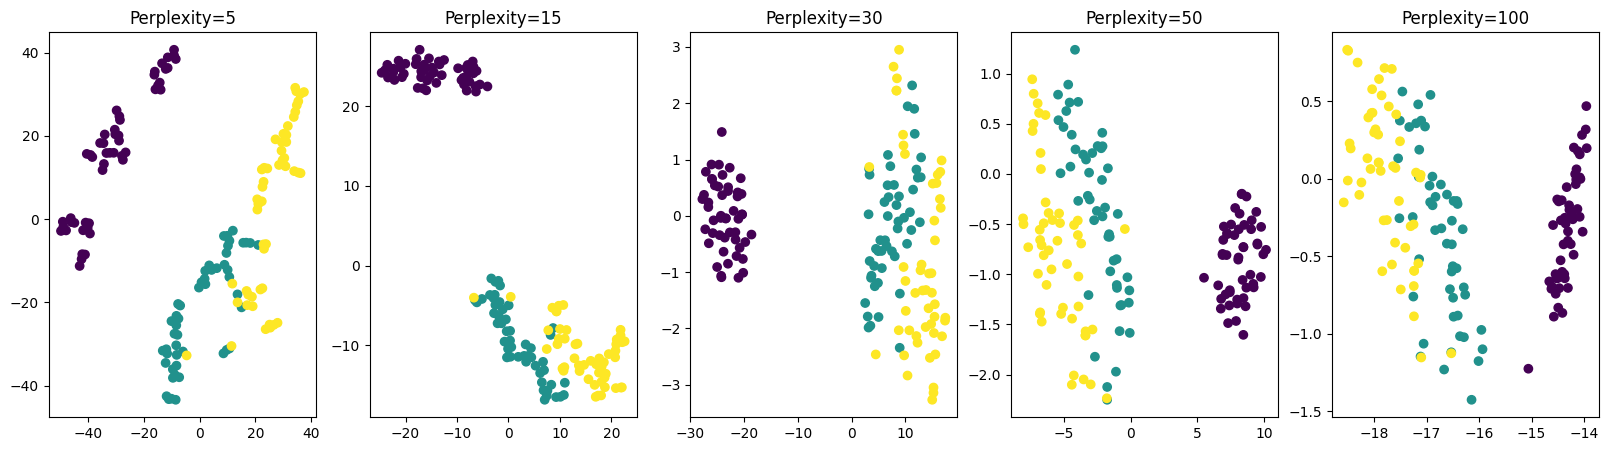

In [41]:
perplexities = [5, 15, 30, 50, 100]

plt.figure(figsize=(20, 5))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p)
    X_new = tsne.fit_transform(X_scaled)

    plt.subplot(1, 5, i+1)
    plt.scatter(X_new[:, 0], X_new[:, 1], c=pd.factorize(y)[0])
    plt.title(f"Perplexity={p}")

plt.show()